# Lab 5 : Exploratory Data Analysis



---



In [1]:
# Import library and Thai font
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import pandas as pd
import os
import matplotlib.cm as cm
import ast
import plotly.express as px
font_path = 'THSarabunNew.ttf'
font_manager.fontManager.addfont(font_path)
rcParams['font.family'] = 'TH Sarabun New'


# Data Preparation

In [2]:
#ใช้ในการ Map ชื่อจังหวัดที่ผิดให้เป็น ชื่อจังหวัดที่ถูกต้อง
province_fix_map = {
    'กรงเทพมหานคร': 'กรุงเทพมหานคร',
    'กระบ': 'กระบี่',
    'กาญจนบร': 'กาญจนบุรี',
    'กาฬสนธ': 'กาฬสินธุ์',
    'กำแพงเพชร': 'กำแพงเพชร',
    'ขอนแกน': 'ขอนแก่น',
    'จนทบร': 'จันทบุรี',
    'ฉะเชงเทรา': 'ฉะเชิงเทรา',
    'ชมพร': 'ชุมพร',
    'ชยนาท': 'ชัยนาท',
    'ชยภม': 'ชัยภูมิ',
    'ชลบร': 'ชลบุรี',
    'ตรง': 'ตรัง',
    'ตราด': 'ตราด',
    'ตาก': 'ตาก',
    'นครนายก': 'นครนายก',
    'นครปฐม': 'นครปฐม',
    'นครพนม': 'นครพนม',
    'นครราชสมา': 'นครราชสีมา',
    'นครศรธรรมราช': 'นครศรีธรรมราช',
    'นครสวรรค': 'นครสวรรค์',
    'นนทบร': 'นนทบุรี',
    'นราธวาส': 'นราธิวาส',
    'นาน': 'น่าน',
    'บงกาฬ': 'บึงกาฬ',
    'บรรมย': 'บุรีรัมย์',
    'ปตตาน': 'ปัตตานี',
    'ปทมธาน': 'ปทุมธานี',
    'ประจวบครขนธ': 'ประจวบคีรีขันธ์',
    'ปราจนบร': 'ปราจีนบุรี',
    'พงงา': 'พังงา',
    'พจตร': 'พิจิตร',
    'พทลง': 'พัทลุง',
    'พระนครศรอยธยา': 'พระนครศรีอยุธยา',
    'พษณโลก': 'พิษณุโลก',
    'พะเยา': 'พะเยา',
    'ภเกต': 'ภูเก็ต',
    'มกดาหาร': 'มุกดาหาร',
    'มหาสารคาม': 'มหาสารคาม',
    'ยะลา': 'ยะลา',
    'ยโสธร': 'ยโสธร',
    'รอยเอด': 'ร้อยเอ็ด',
    'ระนอง': 'ระนอง',
    'ระยอง': 'ระยอง',
    'ราชบร': 'ราชบุรี',
    'ลพบร': 'ลพบุรี',
    'ลำปาง': 'ลำปาง',
    'ลำพน': 'ลำพูน',
    'ศรสะเกษ': 'ศรีสะเกษ',
    'สกลนคร': 'สกลนคร',
    'สงขลา': 'สงขลา',
    'สงหบร': 'สิงห์บุรี',
    'สตล': 'สตูล',
    'สพรรณบร': 'สุพรรณบุรี',
    'สมทรปราการ': 'สมุทรปราการ',
    'สมทรสงคราม': 'สมุทรสงคราม',
    'สมทรสาคร': 'สมุทรสาคร',
    'สรนทร': 'สุรินทร์',
    'สระบร': 'สระบุรี',
    'สระแกว': 'สระแก้ว',
    'สราษฎรธาน': 'สุราษฎร์ธานี',
    'สโขทย': 'สุโขทัย',
    'หนองคาย': 'หนองคาย',
    'หนองบวลำภ': 'หนองบัวลำภู',
    'อดรธาน': 'อุดรธานี',
    'อตรดตถ': 'อุตรดิตถ์',
    'อทยธาน': 'อุทัยธานี',
    'อบลราชธาน': 'อุบลราชธานี',
    'อางทอง': 'อ่างทอง',
    'อำนาจเจรญ': 'อำนาจเจริญ',
    'เชยงราย': 'เชียงราย',
    'เชยงใหม': 'เชียงใหม่',
    'เพชรบร': 'เพชรบุรี',
    'เพชรบรณ': 'เพชรบูรณ์',
    'เลย': 'เลย',
    'แพร': 'แพร่',
    'แมฮองสอน': 'แม่ฮ่องสอน'
}

In [3]:

root_dir = './data/all_constituency'
all_data = [] # All data สำหรับเก็บ df ของแต่ละเขต
# อ่าน File จาก Folder all_constituency 
for subdir, dirs, files in os.walk(root_dir): 
    for file in files:
        if file == 'constituency_candidates.csv': # ชื่อ File ที่จะอ่าน
            file_path = os.path.join(subdir, file)
            
            parts = subdir.split(os.sep)
            
            if len(parts) >= 3:
                province = parts[-2]      # จังหวัด
                constituency = parts[-1]  # เขต
                province_fix = province_fix_map[province] #แก้ชื่อจังหวัด
                constituency_fix = constituency.replace(province,province_fix) # แก้ชื่อเขต
                
                try:
                    temp_df = pd.read_csv(file_path, encoding='utf-8-sig')  # temp_df สำหรับอ่าน csv แต่ละ File

                    temp_df['province'] = province_fix # เพิ่ม Column จังหวัดลงไป
                    temp_df['constituency'] = constituency_fix # เพิ่ม Column เขตลงไป
                    
                    all_data.append(temp_df) 
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")

if all_data: # ถ้ามี df ของแต่ละเขต
    district_df = pd.concat(all_data, ignore_index=True) # นำมารวมกันเป็น df เดียว
 
    cols = ['province', 'constituency'] + [c for c in district_df.columns if c not in ['province', 'constituency']] 
    district_df = district_df[cols] # ย้าย col จังหวัด และ เขต มาอยู่ข้างหน้า


In [4]:
district_df.head() # ได้ district_df ที่มีข้อมูลผู้สมัครแต่ละคนในเขต

,province,constituency,fullName,totalVotes,candidateNumber,updatedAt,percent,rank,party.code,party.color,party.name
0,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,ปารเมศ วิทยารักษ์สรรค์,32564,5,2026-02-07T16:49:10.564Z,44.39,1,46,#ff6412,พรรคประชาชน
1,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,พีรวุฒิ พิมพ์สมฤดี,14018,9,2026-02-07T16:49:14.267Z,19.11,2,27,#70c0fd,พรรคประชาธิปัตย์
2,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,ลลิดา เพริศวิวัฒนา,13661,1,2026-02-07T16:49:03.079Z,18.62,3,37,#131c5f,พรรคภูมิใจไทย
3,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,ญาณกิตติ์ ห่วงทรัพย์,5761,8,2026-02-07T16:49:13.129Z,7.85,4,9,#fe0000,พรรคเพื่อไทย
4,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,พลัฏฐ์ ศิริกุลพิสุทธิ์,1983,6,2026-02-07T16:49:11.214Z,2.70,5,6,#243180,พรรครวมไทยสร้างชาติ


In [5]:
district_df.isnull().sum() # ตรวจสอบความถูกต้องของ district_df

province           0
constituency       0
fullName           0
totalVotes         0
candidateNumber    0
updatedAt          0
percent            0
rank               0
party.code         0
party.color        0
party.name         0
dtype: int64

In [6]:
top2_df = district_df[(district_df["rank"]==1) | (district_df["rank"] ==2)].reset_index(drop=True) 
top2_df.head() #Prepare data ของผู้สมัครสส.แต่ละเขตโดยเลือกแค่ผู้ที่ได้อันดับ 1 และ 2 ในแต่ละเขต

,province,constituency,fullName,totalVotes,candidateNumber,updatedAt,percent,rank,party.code,party.color,party.name
0,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,ปารเมศ วิทยารักษ์สรรค์,32564,5,2026-02-07T16:49:10.564Z,44.39,1,46,#ff6412,พรรคประชาชน
1,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,พีรวุฒิ พิมพ์สมฤดี,14018,9,2026-02-07T16:49:14.267Z,19.11,2,27,#70c0fd,พรรคประชาธิปัตย์
2,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 10,เอกราช อุดมอำนวย,37489,6,2026-02-07T16:49:11.214Z,44.74,1,46,#ff6412,พรรคประชาชน
3,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 10,ภูมิพัฒน์ โหสกุล,17889,5,2026-02-07T16:49:09.941Z,21.35,2,9,#fe0000,พรรคเพื่อไทย
4,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 11,ศศินันท์ ธรรมนิฐินันท์,36844,15,2026-02-07T16:49:15.052Z,40.91,1,46,#ff6412,พรรคประชาชน


# Exploratory Data Analysis (EDA)

In [7]:
def calc_diff(group): # Function คำนวณ % ความต่างของอันดับ 1 และ 2 ในเขตเดียวกัน
    r1 = group[group['rank'] == 1]['percent'].values[0]
    r2 = group[group['rank'] == 2]['percent'].values[0]
    return r1 - r2

percentage_diff = top2_df.groupby("constituency").apply(calc_diff)
print(percentage_diff) #ลองคำนวณ % ความต่าง

constituency
กระบี่ เขต 1            33.10
กระบี่ เขต 2            27.80
กระบี่ เขต 3            36.39
กรุงเทพมหานคร เขต 1     25.28
กรุงเทพมหานคร เขต 10    23.39
                        ...  
แพร่ เขต 1              15.65
แพร่ เขต 2              53.84
แพร่ เขต 3               3.37
แม่ฮ่องสอน เขต 1        27.41
แม่ฮ่องสอน เขต 2         0.45
Length: 400, dtype: float64


C:\Users\lchan\AppData\Local\Temp\ipykernel_5996\1911264329.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  percentage_diff = top2_df.groupby("constituency").apply(calc_diff)


In [8]:
df_diff = top2_df.pivot_table( #สร้าง pivot table ที่ประกอบไปด้วย จังหวัด เขต พรรคอันดับ 1,2 และ % คะแนนทั้งสองพรรค ชื่อ df_diff
    index=['province', 'constituency'], 
    columns='rank', 
    values=['party.name', 'percent'],
    aggfunc='first'
).reset_index()

df_diff.columns = [ #เปลี่ยนชื่อ Column
    'province', 'constituency', 
    'winner_party', 'runnerup_party', 
    'winner_percent', 'runnerup_percent'
]

df_diff['pct_diff'] = df_diff['winner_percent'] - df_diff['runnerup_percent'] #สร้าง Feature % ความต่างของคะแนน

df_diff = df_diff.sort_values('pct_diff').reset_index(drop=True) #sort df_diff ตาม % ความต่างของคะแนน

df_diff.head()

,province,constituency,winner_party,runnerup_party,winner_percent,runnerup_percent,pct_diff
0,นราธิวาส,นราธิวาส เขต 3,พรรคกล้าธรรม,พรรคภูมิใจไทย,45.88,45.74,0.14
1,ศรีสะเกษ,ศรีสะเกษ เขต 6,พรรคภูมิใจไทย,พรรคเพื่อไทย,39.19,38.87,0.32
2,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 2,พรรคภูมิใจไทย,พรรคกล้าธรรม,36.81,36.36,0.45
3,นครราชสีมา,นครราชสีมา เขต 3,พรรคประชาชน,พรรคเพื่อไทย,40.86,40.25,0.61
4,ขอนแก่น,ขอนแก่น เขต 3,พรรคกล้าธรรม,พรรคประชาชน,35.38,34.59,0.79


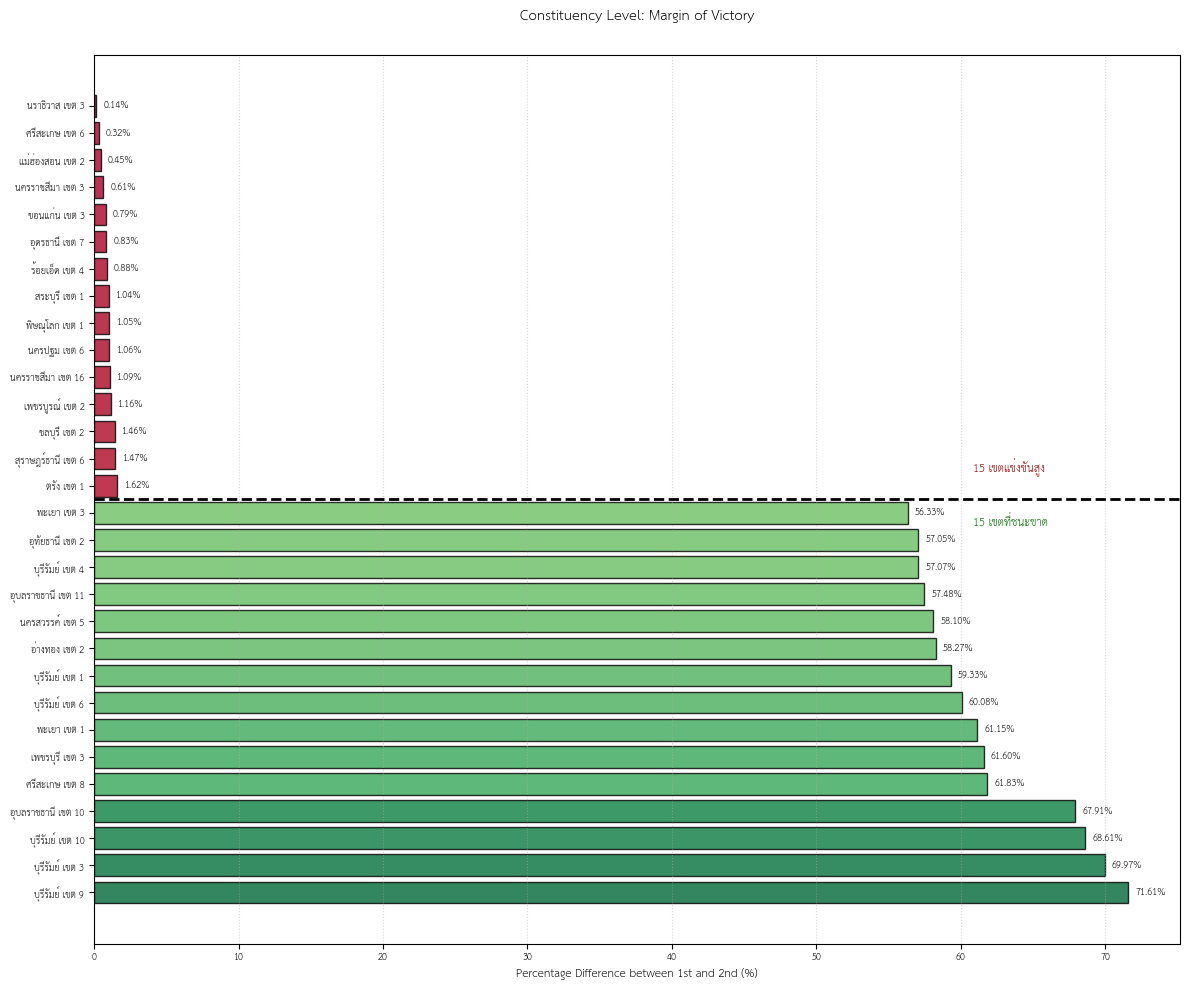

In [9]:
combined_const = pd.concat([df_diff.head(15), df_diff.tail(15)]).sort_values('pct_diff') #เลือกข้อมูลเขตที่มี % ผลต่างคะแนน 15 อันดับแรก และ 15 อันดับสุดท้ายเพื่อมา visualization

labels = combined_const['constituency'] 
values = combined_const['pct_diff']

norm = plt.Normalize(values.min(), values.max())
colors = cm.RdYlGn(norm(values.values)) # ตั้งค่าสีให้สีเขียวคือ % ความต่างมาก(ชนะขาด) สีอดงคือ % ความต่างน้อย(สูสี)

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(labels, values, color=colors, edgecolor='black', alpha=0.8) # plot graph เป็น horizontal bar

split_index = 15 
ax.axhline(y=split_index - 0.5, color='black', linestyle='--', linewidth=2) # สร้างเส้นขั้นระหว่าง 15 อันดับแรก และ 15 อันดับสุดท้าย

ax.text(values.max()*0.85, split_index - 1.5, '15 เขตแข่งขันสูง', 
        color='darkred', fontweight='bold', fontsize=12)
ax.text(values.max()*0.85, split_index + 0.5, '15 เขตที่ชนะขาด', #เขียน text กำกับ 15 อันดับแรก และ 15 อันดับสุดท้าย
        color='darkgreen', fontweight='bold', fontsize=12)

ax.set_title('Constituency Level: Margin of Victory', fontsize=15, pad=25) #ตั้งค่า figure
ax.set_xlabel('Percentage Difference between 1st and 2nd (%)', fontsize=12)
ax.invert_yaxis() 
ax.grid(axis='x', linestyle=':', alpha=0.5)

for bar in bars: #ใส่ text % ลงในแต่ละ bar
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', 
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show() # show graph

In [10]:
province_competition = df_diff.groupby("province")["pct_diff"].mean().sort_values()
province_competition.head() #คำนวณ % ผลต่างคะแนนตามจังหวัด โดยใช้ค่าเฉลี่ยจากเขตทั้งหมดในจังหวัด

province
ภูเก็ต          7.290000
จันทบุรี        7.390000
นครนายก         8.160000
น่าน            8.450000
สุราษฎร์ธานี    9.505714
Name: pct_diff, dtype: float64

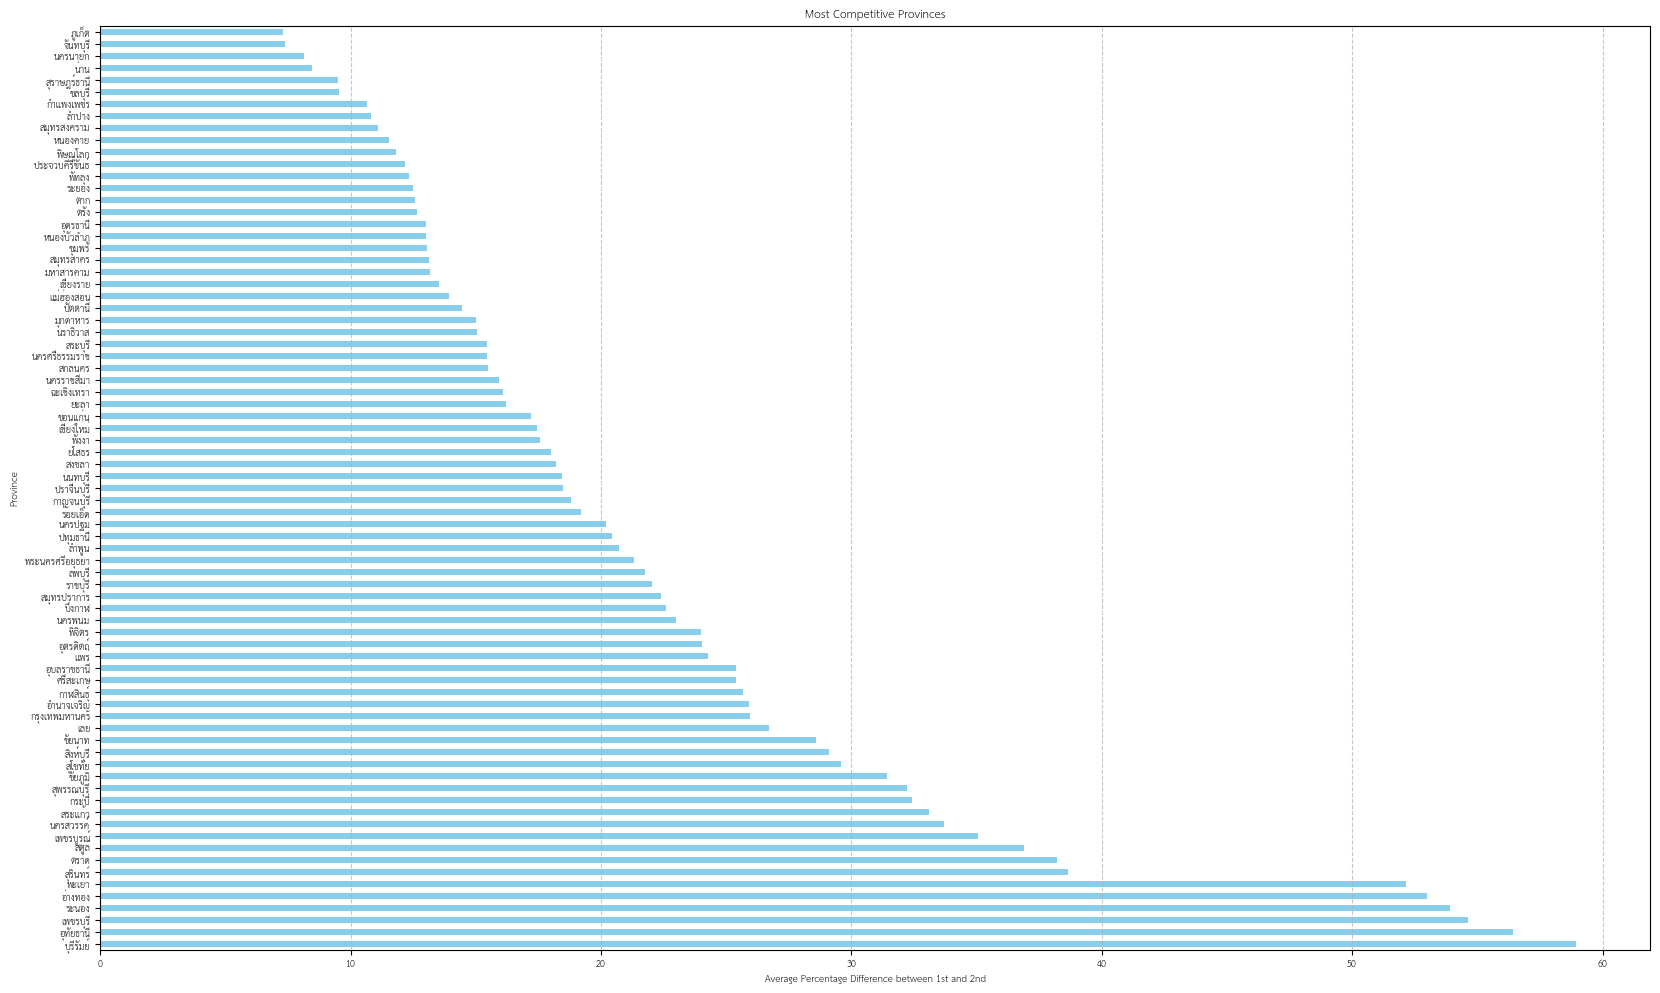

In [11]:
plt.figure(figsize=(20, 12)) 
province_competition.plot(kind='barh', color='skyblue')
#plot horizontal bar จาก % ผลต่างคะแนนตามจังหวัด
plt.title('Most Competitive Provinces')
plt.xlabel('Average Percentage Difference between 1st and 2nd')
plt.ylabel('Province')
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

จาก ข้อมูลที่ visualize แบบภาพรวมมาลอง zoom ดู จังหวัดที่แข่งขันสูง และจังหวัดที่ชนะขาด 

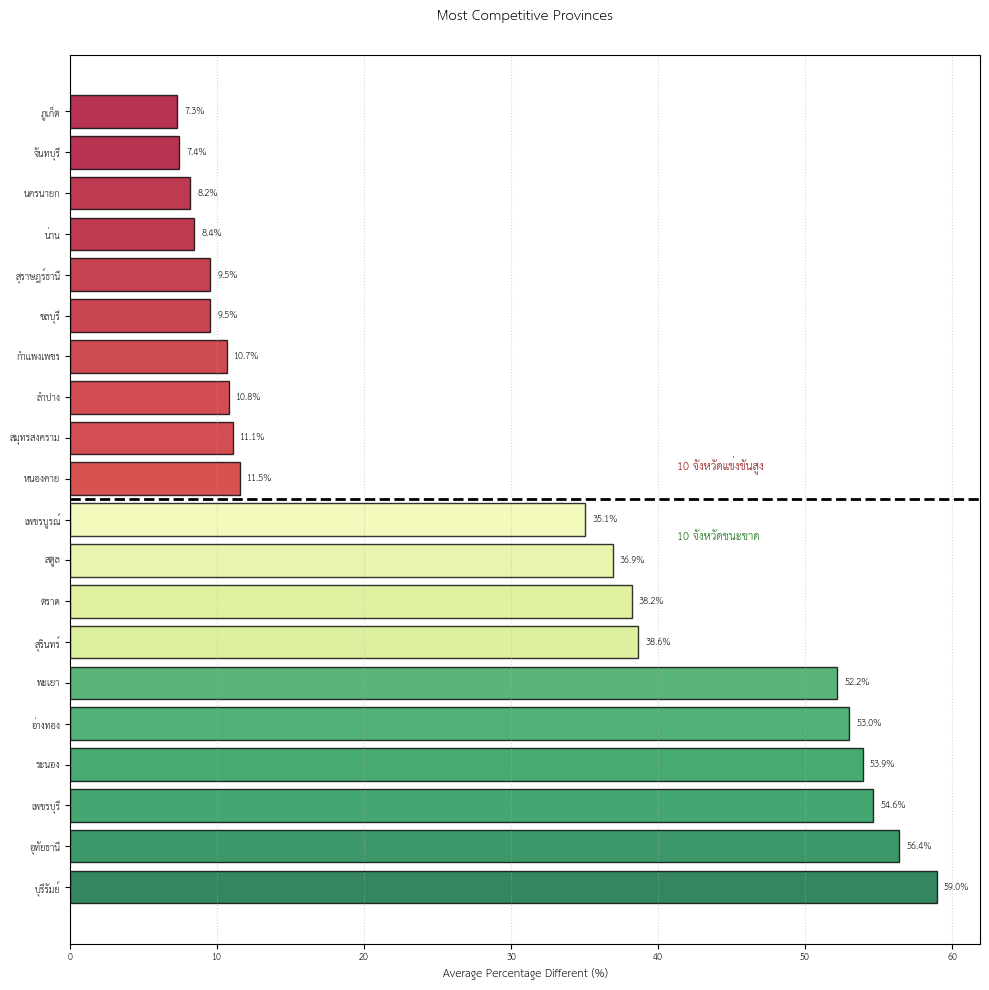

In [12]:
combined = pd.concat([province_competition.head(10), province_competition.tail(10)]).sort_values()

norm = plt.Normalize(combined.min(), combined.max())
colors = cm.RdYlGn(norm(combined.values))

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(combined.index, combined.values, color=colors, edgecolor='black', alpha=0.8)

split_index = 10 
ax.axhline(y=split_index - 0.5, color='black', linestyle='--', linewidth=2)

ax.text(combined.max()*0.7, split_index - 1.2, '10 จังหวัดแข่งขันสูง', 
        color='darkred', fontweight='bold', fontsize=12)
ax.text(combined.max()*0.7, split_index + 0.5, '10 จังหวัดชนะขาด', 
        color='darkgreen', fontweight='bold', fontsize=12)

ax.set_title('Most Competitive Provinces', fontsize=15, pad=25)
ax.set_xlabel('Average Percentage Different (%)', fontsize=12)
ax.invert_yaxis()
ax.grid(axis='x', linestyle=':', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [13]:
district_df.groupby("candidateNumber")["rank"].agg("mean") #หาอันดับเฉลี่ย สส. เขตจากหมายเลขผู้สมัคร

candidateNumber
1      4.062972
2      4.375000
3      4.376263
4      4.335013
5      4.382278
6      4.875661
7      5.705706
8      6.827586
9      5.430108
10     9.042735
11     7.527778
12     9.956522
13    10.083333
14    10.344828
15    10.150000
16    12.866667
17    10.600000
18    14.000000
19    19.000000
Name: rank, dtype: float64

In [14]:
pivot_rank = district_df.pivot_table( # นำข้อมูลอันดับเฉลี่ย สส. เขตจากหมายเลขผู้สมัคร มาสร้างเป็น pivot table
    index='candidateNumber', 
    values='rank', 
    aggfunc='mean'
)

pivot_rank = pivot_rank.sort_values('rank') # จัดเรียง pivot table จากเลขที่มีอันดับเฉลี่ยดีที่สุด
pivot_rank

,rank
candidateNumber,
1,4.062972
4,4.335013
2,4.375000
3,4.376263
5,4.382278
6,4.875661
9,5.430108
7,5.705706
8,6.827586


จะเห็นค่าแปลก ๆ อย่างเช่น หมายเลข 19 ได้ อันดับ 19

In [15]:
candidate_count = district_df.groupby(['province', 'constituency'])["candidateNumber"].count().reset_index() 
candidate_count.columns = ['province', 'constituency', 'candidate_total']
candidate_count #สร้าง df candidate_count นับจำนวนผู้สมัครในแต่ละเขต

,province,constituency,candidate_total
0,กระบี่,กระบี่ เขต 1,6
1,กระบี่,กระบี่ เขต 2,7
2,กระบี่,กระบี่ เขต 3,6
3,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,18
4,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 10,16
...,...,...,...
395,แพร่,แพร่ เขต 1,6
396,แพร่,แพร่ เขต 2,5
397,แพร่,แพร่ เขต 3,6
398,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 1,5


In [16]:
candidate_count_freq = candidate_count["candidate_total"].value_counts().reset_index()
candidate_count_freq # นับความถี่เขตตามจำนวนผู้สมัคร

,candidate_total,count
0,7,75
1,8,75
2,9,62
3,6,52
4,10,47
5,11,24
6,5,15
7,12,12
8,16,9
9,14,9


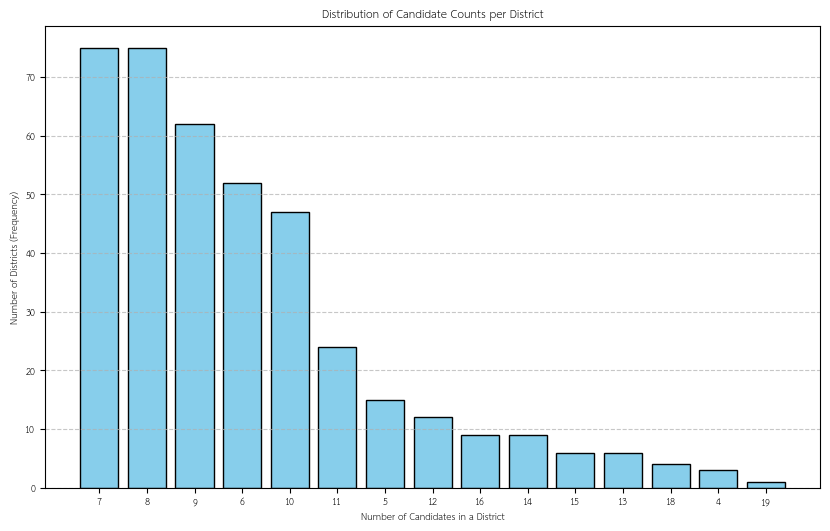

In [17]:
#plot bar graph นับความถี่เขตตามจำนวนผู้สมัคร
plt.figure(figsize=(10, 6))
plt.bar(candidate_count_freq['candidate_total'].astype(str), candidate_count_freq['count'], color='skyblue', edgecolor='black')

plt.title('Distribution of Candidate Counts per District')
plt.xlabel('Number of Candidates in a District')
plt.ylabel('Number of Districts (Frequency)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

เห็นว่าเขตส่วนใหญ่จะมีจำนวนผู้สมัคร 6 - 10 คน และแต่ละเขตต้องมีผู้สมัครอย่างน้อย 4 คน

In [18]:
#Prepare data ของผู้สมัครสส.แต่ละเขตโดยเลือกแค่ผู้ที่ได้อันดับ 1, 2 และ 3 ในแต่ละเขต
top3_rank_df = district_df[district_df['rank'].isin([1, 2, 3])]

#สร้าง pivor table นับจำนวนการได้อันดับ 1,2 และ 3 แต่ละหมายเลขผู้สมัคร
rank_pivot = top3_rank_df.pivot_table(
    index='candidateNumber', 
    columns='rank', 
    values='fullName',
    aggfunc='count',
    fill_value=0
).reset_index()

#สร้าง column อันดับเฉลี่ยของแต่ละหมายเลข
rank_pivot.columns = ['candidateNumber','R1', 'R2', 'R3']
rank_pivot['mean_rank'] = ((1 * rank_pivot['R1']) + (2 * rank_pivot['R2']) + (3 * rank_pivot['R3'])) / (rank_pivot['R1'] + rank_pivot['R2'] + rank_pivot['R3'])
rank_pivot

,candidateNumber,R1,R2,R3,mean_rank
0,1,58,61,68,2.053476
1,2,61,64,63,2.010638
2,3,63,65,56,1.961957
3,4,55,65,55,2.000000
4,5,74,44,59,1.915254
5,6,34,43,39,2.043103
6,7,26,30,24,1.975000
7,8,13,14,17,2.090909
8,9,4,5,8,2.235294
9,10,3,3,2,1.875000


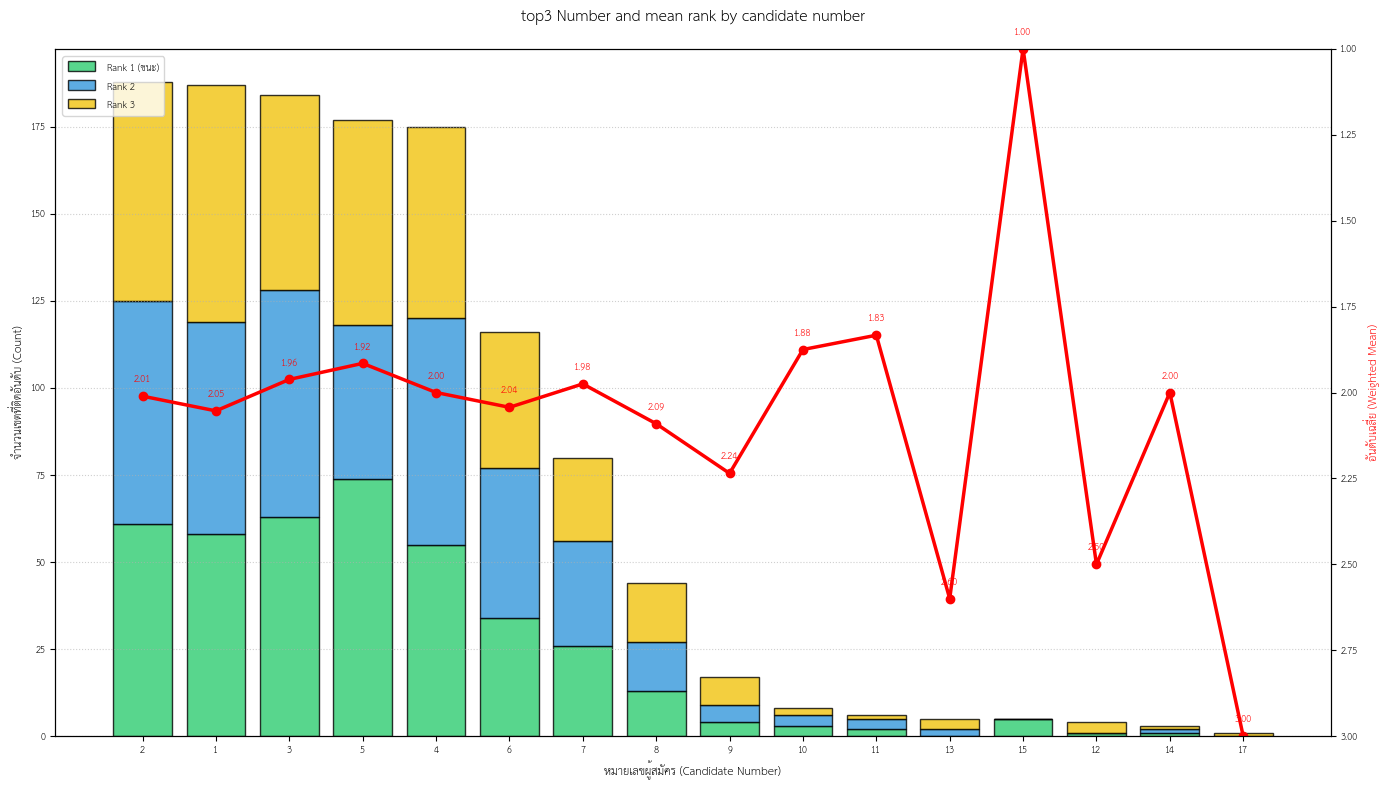

In [19]:
#จัดเรียงการ plot ตามผลรวม top 3 
rank_pivot['total_top3'] = rank_pivot['R1'] + rank_pivot['R2'] + rank_pivot['R3']
plot_df = rank_pivot.sort_values('total_top3', ascending=False)

fig, ax1 = plt.subplots(figsize=(14, 8))

#plot จำนวนการได้ที่ 1 เป็นสีเขียว ที่ 2 เป็นสีน้ำเงิน และที่ 3 เป็นสีเหลือง ในทุก ๆ หมายเลขผู้สมัคร
x = plot_df['candidateNumber'].astype(str)
ax1.bar(x, plot_df['R1'], color='#2ecc71', label='Rank 1 (ชนะ)', edgecolor='black', alpha=0.8)
ax1.bar(x, plot_df['R2'], bottom=plot_df['R1'], color='#3498db', label='Rank 2', edgecolor='black', alpha=0.8)
ax1.bar(x, plot_df['R3'], bottom=plot_df['R1'] + plot_df['R2'], color='#f1c40f', label='Rank 3', edgecolor='black', alpha=0.8)

#ตั้งค่าการ label
ax1.set_xlabel('หมายเลขผู้สมัคร (Candidate Number)', fontsize=12)
ax1.set_ylabel('จำนวนเขตที่ติดอันดับ (Count)', fontsize=12)
ax1.legend(loc='upper left')

#plot อันดับเฉลี่ยเป็น line graph สีแดง
ax2 = ax1.twinx()
ax2.plot(x, plot_df['mean_rank'], color='red', marker='o', linewidth=2.5, label='Mean Rank (1-3)')
ax2.set_ylabel('อันดับเฉลี่ย (Weighted Mean)', color='red', fontsize=12)
ax2.set_ylim(1, 3) 
ax2.invert_yaxis() 

#label ของอันดับเฉลี่ย
for i, val in enumerate(plot_df['mean_rank']):
    ax2.annotate(f'{val:.2f}', (i, val), textcoords="offset points", xytext=(0,10), 
                 ha='center', color='red', fontweight='bold')

plt.title('top3 Number and mean rank by candidate number', fontsize=16, pad=20)
ax1.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

จะเห็นว่าหมายเลข 2 มีจำนวนการติด top 3 มากที่สุด ส่วนหมายเลข 5 มีจำนวนที่ 1 มากที่สุด และหมายเลข 15 ได้ที่ 1 ทั้งหมด 5 ครั้ง และมีอันดับเฉลี่ย คือ 1 

In [20]:
#ตรวจสอบข้อมูลผู้สมัครหมายเลข 15 ที่ได้ ที่ 1
district_df[(district_df["candidateNumber"] == 15) & (district_df["rank"] ==1)]

,province,constituency,fullName,totalVotes,candidateNumber,updatedAt,percent,rank,party.code,party.color,party.name
34,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 11,ศศินันท์ ธรรมนิฐินันท์,36844,15,2026-02-07T16:49:15.052Z,40.91,1,46,#ff6412,พรรคประชาชน
52,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 12,ภูริวรรธก์ ใจสำราญ,44824,15,2026-02-07T16:49:15.052Z,47.72,1,46,#ff6412,พรรคประชาชน
234,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 23,ชลธาร ทรัพย์ไพบูลย์เลิศ,44381,15,2026-02-07T16:49:15.312Z,49.76,1,46,#ff6412,พรรคประชาชน
348,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 30,ธัญธร ธนินวัฒนาธร,44737,15,2026-02-07T16:49:15.052Z,49.82,1,46,#ff6412,พรรคประชาชน
383,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 32,ปวิตรา จิตตกิจ,36963,15,2026-02-07T16:49:15.052Z,46.17,1,46,#ff6412,พรรคประชาชน


พบว่าเป็นพรรคประชาชนทั้งหมด

In [21]:
#สร้าง party_mode_df ว่าผู้สมัคร สส. เขตใช้หมายเลขใดมากที่สุดในแต่ละพรรค
party_mode_df = district_df.groupby("party.name")["candidateNumber"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
).reset_index()

party_mode_df.columns = ['party_name', 'mode_candidate_number']
party_mode_df

,party_name,mode_candidate_number
0,พรรคกรีน,5
1,พรรคกล้าธรรม,4
2,พรรคก้าวอิสระ,5
3,พรรคครูไทยเพื่อประชาชน,8
4,พรรคคลองไทย,4
5,พรรคความหวังใหม่,15
6,พรรคทางเลือกใหม่,8
7,พรรคท้องที่ไทย,1
8,พรรคประชากรไทย,9
9,พรรคประชาชน,2


In [22]:
#สร้าง party_mode_df ว่าผู้สมัคร สส. เขตที่ได้อันดับ 1 ใช้หมายเลขใดมากที่สุดในแต่ละพรรค
top1_df = district_df[district_df["rank"]==1].reset_index()
top1_party_mode_df = top1_df.groupby("party.name")["candidateNumber"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
).reset_index()

top1_party_mode_df.columns = ['party_name', 'rank1_mode_candidate_number']
top1_party_mode_df

,party_name,rank1_mode_candidate_number
0,พรรคกล้าธรรม,3
1,พรรคประชาชน,7
2,พรรคประชาชาติ,3
3,พรรคประชาธิปัตย์,5
4,พรรคพลังประชารัฐ,3
5,พรรคภูมิใจไทย,5
6,พรรคเพื่อไทย,1
7,พรรคโอกาสใหม่,4
8,พรรคไทยสร้างไทย,4
9,พรรคไทรวมพลัง,5


In [23]:
#merge ทั้งสอง df ก่อนหน้านี้เพื่อเปรียบเทียบเลขมงคลของแต่ละพรรค
party_mode_compare = pd.merge(
    top1_party_mode_df,
    party_mode_df, 
    on='party_name', 
    how='left', 
    suffixes=('_overall', '_winner')
)
party_mode_compare

,party_name,rank1_mode_candidate_number,mode_candidate_number
0,พรรคกล้าธรรม,3,4
1,พรรคประชาชน,7,2
2,พรรคประชาชาติ,3,1
3,พรรคประชาธิปัตย์,5,5
4,พรรคพลังประชารัฐ,3,6
5,พรรคภูมิใจไทย,5,5
6,พรรคเพื่อไทย,1,1
7,พรรคโอกาสใหม่,4,2
8,พรรคไทยสร้างไทย,4,5
9,พรรคไทรวมพลัง,5,2


In [24]:
#filter ให้เหลือแค่พรรคที่ผู้สมัครส่วนใหญ่มีหมายเลขตรงกับหมายเลขที่ส่วนใหญ่ได้ที่ 1
party_mode_compare[party_mode_compare["rank1_mode_candidate_number"]==party_mode_compare["mode_candidate_number"]]

,party_name,rank1_mode_candidate_number,mode_candidate_number
3,พรรคประชาธิปัตย์,5,5
5,พรรคภูมิใจไทย,5,5
6,พรรคเพื่อไทย,1,1


In [25]:
partylistdf = pd.read_csv('data/partylist/party_list_top2.csv') # Load data คะแนน partylist ของแต่ละเขต
partylistdf.isnull().sum() # ตรวจสอบความถูกต้องของ partylistdf

id                0
name              0
provinceId        0
number            0
provinceName      0
parties           0
provinceId_key    0
dtype: int64

In [26]:
partylistdf
cleanparty = []

for index, row in partylistdf.iterrows():
    
    parties_data = ast.literal_eval(row['parties'])
    
   
    if parties_data: 
            winner = max(parties_data, key=lambda x: x['totalVotes'])

            cleanparty.append({
                'provinceName': row['provinceName'],
                'contituency' : row['name'],
                'Winner_Party': winner['party']['name'],
                'Votes': winner['totalVotes'],
                'Percent': winner['percent'],
                'Color': winner['party']['color'] 
            })

partylistwinner = pd.DataFrame(cleanparty)
partylistwinner  # ได้ dataframe partylistwinner ที่มีข้อมูลผู้ชนะ Partylist ในเขต และคะแนน


,provinceName,contituency,Winner_Party,Votes,Percent,Color
0,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,พรรคประชาชน,32377,43.450312,#ff6412
1,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 2,พรรคประชาชน,37773,46.746448,#ff6412
2,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 3,พรรคประชาชน,34103,45.466423,#ff6412
3,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 4,พรรคประชาชน,31995,44.897071,#ff6412
4,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 5,พรรคประชาชน,43941,49.740211,#ff6412
...,...,...,...,...,...,...
395,นราธิวาส,นราธิวาส เขต 1,พรรคประชาชาติ,26389,30.277545,#ba810e
396,นราธิวาส,นราธิวาส เขต 2,พรรคประชาชน,14722,23.074873,#ff6412
397,นราธิวาส,นราธิวาส เขต 3,พรรคประชาชาติ,20935,29.992407,#ba810e
398,นราธิวาส,นราธิวาส เขต 4,พรรคประชาชาติ,27823,36.271315,#ba810e


In [27]:
partyStand = pd.read_csv('data/party/partyStandings.csv') # Load data ข้อมูลของแต่ละพรรค (ที่นั่งสส.,คะแนนPartylist,คะแนนแบ่งเขต)
partyStand.isnull().sum() # ตรวจสอบความถูกต้องของ partyStand

id                        0
partyName                 0
constituencySeats         0
partyListSeats            0
totalSeats                0
totalPartyListVotes       0
totalConstituencyVotes    0
color                     0
dtype: int64

In [28]:
partyStand = partyStand.sort_values(by="id").reset_index(drop=True) # Sort partyStand ตาม Id ของพรรค
partyStand.head() 

,id,partyName,constituencySeats,partyListSeats,totalSeats,totalPartyListVotes,totalConstituencyVotes,color
0,1,พรรคไทยทรัพย์ทวี,0,1,1,284761,2440,#e41d24
1,2,พรรคเพื่อชาติไทย,0,2,2,628493,459,#ffe724
2,3,พรรคใหม่,0,1,1,294239,653,#101e41
3,4,พรรคมิติใหม่,0,1,1,230170,1205,#02137d
4,5,พรรครวมใจไทย,0,1,1,403671,2638,#e10717


In [29]:
# สร้าง Column Percentage Gap ระหว่างคะแนนโหวตของสส.บัญชีรายกับสส.เขต
# ถ้าเป็น Percet บวก จะหมายถึงคนที่โหวตเลือกพรรคมากกว่าเลือกคน 
# แต่ถ้าเป็นลบจะหมายถึงคนโหวตเลือกคนมากกว่าเลือกพรรค
partyStand['PctGap'] = ((partyStand['totalPartyListVotes'] - partyStand['totalConstituencyVotes'])/(partyStand['totalPartyListVotes']+partyStand['totalConstituencyVotes'])) *100
partyStand.head()

,id,partyName,constituencySeats,partyListSeats,totalSeats,totalPartyListVotes,totalConstituencyVotes,color,PctGap
0,1,พรรคไทยทรัพย์ทวี,0,1,1,284761,2440,#e41d24,98.300842
1,2,พรรคเพื่อชาติไทย,0,2,2,628493,459,#ffe724,99.854043
2,3,พรรคใหม่,0,1,1,294239,653,#101e41,99.557126
3,4,พรรคมิติใหม่,0,1,1,230170,1205,#02137d,98.958401
4,5,พรรครวมใจไทย,0,1,1,403671,2638,#e10717,98.701481


In [30]:
partyStand = partyStand.sort_values(by='PctGap', ascending=True)
party_color_map = dict(zip(partyStand['partyName'], partyStand['color']))
dynamic_height = len(partyStand) * 30 + 100
#plot bar chart แนวนอน ให้ x เป็น Percent และ y เป็นชื่อพรรค
fig = px.bar(
    partyStand,
    x='PctGap',
    y='partyName',
    orientation='h',
    color='partyName', 
    color_discrete_map=party_color_map,
    title='เปรียบเทียบเปอร์เซ็ตระหว่างคะแนนโหวตของสส.บัญชีรายกับสส.เขต',
    
    hover_data={
        'partyName': True,
        'PctGap': ':.2f',
        'totalPartyListVotes': ':,',    
        'totalConstituencyVotes': ':,', 
    },

    labels={
        'PctGap': 'ส่วนต่างคะแนน (%)', 
        'partyName': 'ชื่อพรรค',
        'totalPartyListVotes': 'คะแนนปาร์ตี้ลิสต์',
        'totalConstituencyVotes': 'คะแนนเขต'
    },

    text_auto='.2f',
    height=dynamic_height
)
# update layout ของ Graph
fig.update_layout(
    showlegend=False,             
    margin=dict(l=150),            
    xaxis=dict(range=[-100, 100]) 
)

# สร้างเส้นแบ่งตรง 0 %
fig.add_vline(x=0, line_width=2, line_color="black")

fig.show()

จะเห็นว่าแต่ละพรรคมีกลยุทธ์ในการสร้างฐานคะแนนไม่เหมือนกัน เช่น พรรคกล้าธรรมเป็นพรรคที่เน้นสสตัวบุคคลมากที่สุด


In [31]:
# หาว่าแต่ละจังหวัดพรรคไหนได้คะแนนโหวต สส.บัญชีรายชื่อมากที่สุด
province_winner = partylistwinner.groupby(['provinceName', 'Winner_Party', 'Color'])['Votes'].sum().reset_index()
df_map = province_winner.sort_values('Votes', ascending=False).drop_duplicates('provinceName')

summary = df_map['Winner_Party'].value_counts().reset_index()
summary.columns = ['พรรค', 'จำนวนจังหวัดที่ชนะ']
print(summary)

               พรรค  จำนวนจังหวัดที่ชนะ
0       พรรคประชาชน                  38
1     พรรคภูมิใจไทย                  13
2      พรรคเพื่อไทย                  13
3  พรรคประชาธิปัตย์                   9
4     พรรคประชาชาติ                   3
5      พรรคกล้าธรรม                   1


In [32]:
# หาว่าแต่ละเขต พรรคไหนได้คะแนนโหวต สส.บัญชีรายชื่อมากที่สุด
partywin_summary = partylistwinner['Winner_Party'].value_counts().reset_index()
partywin_summary.columns = ['Winner_Party', 'zone']
party_colors = dict(zip(partylistwinner['Winner_Party'], partylistwinner['Color']))

print(partywin_summary)

       Winner_Party  zone
0       พรรคประชาชน   205
1      พรรคเพื่อไทย    74
2     พรรคภูมิใจไทย    60
3  พรรคประชาธิปัตย์    43
4     พรรคประชาชาติ    11
5      พรรคกล้าธรรม     3
6     พรรคไทรวมพลัง     3
7  พรรคพลังประชารัฐ     1


In [33]:
#plot bar chart แนวนอน ให้ x เป็น จำนวนเขตที่ชนะ และ y เป็นชื่อพรรค
fig = px.bar(
    partywin_summary,
    x='zone',                   
    y='Winner_Party',            
    orientation='h',            
    color='Winner_Party',        
    color_discrete_map=party_colors, 
    text='zone',              
    title='จำนวนเขตที่พรรคชนะอันดับ 1 (คะแนนบัญชีรายชื่อ)',
    labels={'Winner_Party': 'ชื่อพรรค', 'zone': 'จำนวนเขตที่ชนะ'},
    height=max(400, len(partywin_summary) * 40) 
)


fig.update_layout(
    showlegend=False,
    margin=dict(l=200, r=50, t=80, b=50), 
    xaxis_title="จำนวนเขต (Constituency)",
    yaxis_title="",
    plot_bgcolor='white',
    title={
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    }
)

fig.update_traces(
    textposition='outside', 
    cliponaxis=False
)

fig.show()

In [34]:
# Filter หาว่าพรรคไหนชนะสส.เขต
zonewinner = district_df[district_df['rank'] == 1]
zonewinner

,province,constituency,fullName,totalVotes,candidateNumber,updatedAt,percent,rank,party.code,party.color,party.name
0,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,ปารเมศ วิทยารักษ์สรรค์,32564,5,2026-02-07T16:49:10.564Z,44.39,1,46,#ff6412,พรรคประชาชน
18,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 10,เอกราช อุดมอำนวย,37489,6,2026-02-07T16:49:11.214Z,44.74,1,46,#ff6412,พรรคประชาชน
34,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 11,ศศินันท์ ธรรมนิฐินันท์,36844,15,2026-02-07T16:49:15.052Z,40.91,1,46,#ff6412,พรรคประชาชน
52,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 12,ภูริวรรธก์ ใจสำราญ,44824,15,2026-02-07T16:49:15.052Z,47.72,1,46,#ff6412,พรรคประชาชน
68,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 13,เรืออากาศโทธนเดช เพ็งสุข,39644,7,2026-02-07T16:49:12.470Z,49.62,1,46,#ff6412,พรรคประชาชน
...,...,...,...,...,...,...,...,...,...,...,...
3460,แพร่,แพร่ เขต 1,ชนกนันท์ ศุภศิริ,34337,1,2026-02-07T16:49:03.079Z,42.56,1,37,#131c5f,พรรคภูมิใจไทย
3466,แพร่,แพร่ เขต 2,ชนาธิป ศุภศิริ,50300,1,2026-02-07T16:49:03.079Z,70.08,1,37,#131c5f,พรรคภูมิใจไทย
3471,แพร่,แพร่ เขต 3,ลักษณารีย์ ดวงตาดำ,23574,4,2026-02-07T16:49:09.009Z,32.60,1,46,#ff6412,พรรคประชาชน
3477,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 1,ปกรณ์ จีนาคำ,33724,2,2026-02-07T16:49:06.180Z,58.34,1,42,#44a26e,พรรคกล้าธรรม


In [35]:
# หาว่าแต่ละเขต พรรคไหนได้รับคะแนนโหวต สส.เขตมากที่สุด
zonewin_summary = zonewinner['party.name'].value_counts().reset_index()
zonewin_summary.columns = ['Winner_Party', 'zone']
party_colors = dict(zip(zonewinner['party.name'], zonewinner['party.color']))

print(zonewin_summary)

       Winner_Party  zone
0     พรรคภูมิใจไทย   174
1       พรรคประชาชน    87
2      พรรคเพื่อไทย    58
3      พรรคกล้าธรรม    56
4  พรรคประชาธิปัตย์    10
5     พรรคไทรวมพลัง     5
6     พรรคประชาชาติ     4
7  พรรคพลังประชารัฐ     4
8   พรรคไทยสร้างไทย     1
9     พรรคโอกาสใหม่     1


In [36]:
#plot bar chart แนวนอน ให้ x เป็น จำนวนเขตที่ชนะ และ y เป็นชื่อพรรค
fig = px.bar(
    zonewin_summary,
    x='zone',                  
    y='Winner_Party',            
    orientation='h',             
    color='Winner_Party',       
    color_discrete_map=party_colors, 
    text='zone',                
    title='จำนวนเขตที่พรรคชนะอันดับ 1 (คะแนนแบ่งเขต)',
    labels={'Winner_Party': 'ชื่อพรรค', 'zone': 'จำนวนเขตที่ชนะ'},
    height=max(400, len(zonewin_summary) * 40) 
)

fig.update_layout(
    showlegend=False,
    margin=dict(l=200, r=50, t=80, b=50), 
    xaxis_title="จำนวนเขต (Constituency)",
    yaxis_title="",
    plot_bgcolor='white',
    title={
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    }
)

fig.update_traces(
    textposition='outside', 
    cliponaxis=False
)

fig.show()

In [37]:
# merge dataframe ระหว่าง พรรคที่ชนะสส.แบ่งเขต กับพรรคที่ชนะบัญชีรายชื่อ
df_merge = pd.merge(
    zonewinner[['province', 'constituency', 'party.name']], 
    partylistwinner[['provinceName', 'contituency', 'Winner_Party']], 
    left_on=['province', 'constituency'], 
    right_on=['provinceName', 'contituency']
)

results = []
# ดูว่าพรรคไหนมีผลโหวตมากที่สุดในแต่ละเขต (ทั้งแบบบัญชีรายชื่อและแบบแบ่งเขต)
all_parties = set(df_merge['party.name']).union(set(df_merge['Winner_Party']))

# แบ่งว่าพรรคชนะทั้งคู่หรือชนะแค่อย่างใดอย่างนึง
for party in all_parties:
    # ชนะทั้งคู่
    both = len(df_merge[(df_merge['party.name'] == party) & (df_merge['Winner_Party'] == party)])
    # ชนะแค่ปาร์ตี้ลิสต์
    list_only = len(df_merge[(df_merge['party.name'] != party) & (df_merge['Winner_Party'] == party)])
    # ชนะแค่เขต
    zone_only = len(df_merge[(df_merge['party.name'] == party) & (df_merge['Winner_Party'] != party)])
    
    if both + list_only + zone_only > 0:
        results.append({'Party': party, 'Status': 'ชนะทั้งคู่', 'Count': both})
        results.append({'Party': party, 'Status': 'ชนะแค่ปาร์ตี้ลิสต์', 'Count': list_only})
        results.append({'Party': party, 'Status': 'ชนะแค่เขต', 'Count': zone_only})

final_df = pd.DataFrame(results)

In [44]:
final_df

,Party,Status,Count
0,พรรคไทยสร้างไทย,ชนะทั้งคู่,0
1,พรรคไทยสร้างไทย,ชนะแค่ปาร์ตี้ลิสต์,0
2,พรรคไทยสร้างไทย,ชนะแค่เขต,1
3,พรรคกล้าธรรม,ชนะทั้งคู่,3
4,พรรคกล้าธรรม,ชนะแค่ปาร์ตี้ลิสต์,0
5,พรรคกล้าธรรม,ชนะแค่เขต,53
6,พรรคประชาชน,ชนะทั้งคู่,86
7,พรรคประชาชน,ชนะแค่ปาร์ตี้ลิสต์,119
8,พรรคประชาชน,ชนะแค่เขต,1
9,พรรคพลังประชารัฐ,ชนะทั้งคู่,1


In [45]:

fig = px.bar(
    final_df,
    y='Party',
    x='Count',
    color='Status',
    orientation='h',

    color_discrete_map={
        'ชนะทั้งคู่': '#22c55e',       
        'ชนะแค่ปาร์ตี้ลิสต์': '#3b82f6',
        'ชนะแค่เขต': '#f59e0b'         
    },
    title='สรุปประเภทที่ชนะรายพรรค: ชนะทั้งคู่ vs ชนะระบบเดียว',
    labels={'Count': 'จำนวนเขต', 'Party': 'พรรค', 'Status': 'ประเภทชัยชนะ'},
    text_auto=True
)

fig.update_layout(
    barmode='stack', 
    yaxis={'categoryorder':'total ascending'},
    margin=dict(l=200, r=50, t=80, b=50),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()